In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch

C:\Users\NEHA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 LOAD DATASET

In [2]:
fake = pd.read_csv(r"C:\Users\NEHA\Downloads\Fake(5).csv", encoding="latin1", engine="python", on_bad_lines="skip")
real = pd.read_csv(r"C:\Users\NEHA\Downloads\True(5).csv", encoding="latin1", engine="python", on_bad_lines="skip")

In [3]:
fake["label"] = 0
real["label"] = 1

COMBINE DATASET

In [4]:
data = pd.concat([fake, real], axis=0)

data = data[["text","label"]]

data.head()

,text,label
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


SHUFFLE DATASET

In [5]:
data = data.sample(frac=1).reset_index(drop=True)

EDA

In [6]:
data.shape

(21609, 2)

class distribution

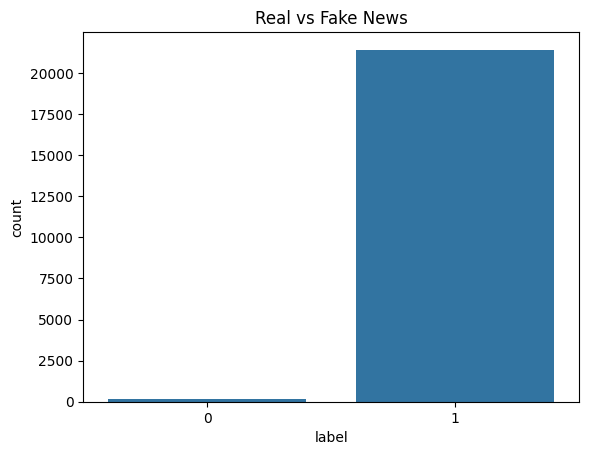

In [7]:
sns.countplot(x="label", data=data)
plt.title("Real vs Fake News")
plt.show()

text length

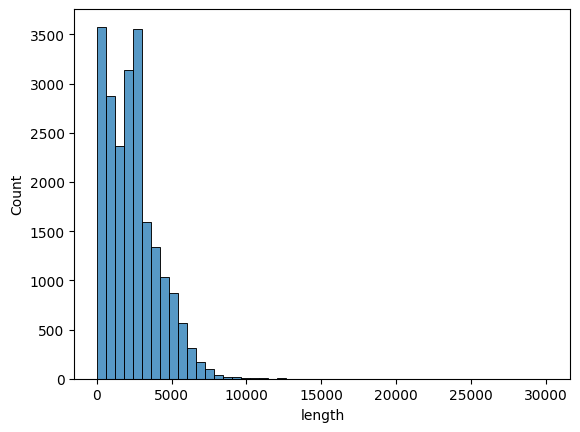

In [8]:
data["length"] = data["text"].astype(str).apply(len)

sns.histplot(data["length"], bins=50)
plt.show()

WordCloud

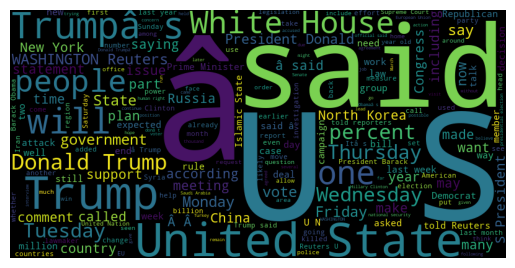

In [9]:

data["text"] = data["text"].astype(str)

text = " ".join(data["text"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

TEXT CLEANING

In [10]:
def clean_text(text):
    
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)

    return text

In [11]:
data["text"] = data["text"].apply(clean_text)

TRAIN TEST SPLIT

In [12]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

TF-IDF VECTORIZATION

In [13]:
tfidf = TfidfVectorizer(stop_words="english",max_df=0.7)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

TRAIN ML MODEL

In [14]:
model = PassiveAggressiveClassifier(max_iter=50)

model.fit(X_train_tfidf,y_train)

PassiveAggressiveClassifier(max_iter=50)

PREDICTION

In [15]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

EVALUATION METRICS

In [16]:
accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


CONFUSION MATRIX

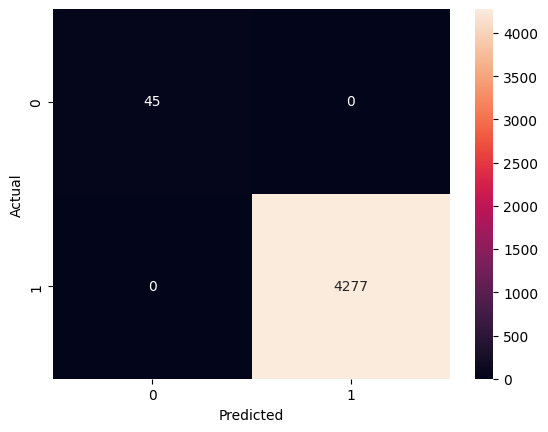

In [17]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

HYPERPARAMETER TUNING

In [18]:
param_grid = {

"max_iter":[30,50,100],

"C":[0.1,1,10]

}

grid = GridSearchCV(
PassiveAggressiveClassifier(),
param_grid,
cv=5
)

grid.fit(X_train_tfidf,y_train)

print(grid.best_params_)

{'C': 0.1, 'max_iter': 30}


SAVE MODEL

In [19]:
joblib.dump(model,"models/fake_news_model.pkl")
joblib.dump(tfidf,"models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']

Train BERT Model

In [20]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
 
model_bert = BertForSequenceClassification.from_pretrained(
"bert-base-uncased",
num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
train_encodings = tokenizer(
list(X_train),
truncation=True,
padding=True,
max_length=512
)

In [22]:
print(torch.__version__)

2.8.0+cpu


In [23]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(

output_dir="./results",

num_train_epochs=2,

per_device_train_batch_size=8

)

In [24]:
model_bert.save_pretrained("../models/fake_news_bert")

tokenizer.save_pretrained("../models/fake_news_bert")

('../models/fake_news_bert\\tokenizer_config.json',
 '../models/fake_news_bert\\special_tokens_map.json',
 '../models/fake_news_bert\\vocab.txt',
 '../models/fake_news_bert\\added_tokens.json')